In [ ]:
import os, zipfile, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()

Saving data.zip to data.zip


In [ ]:
with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
def find_dir(target):
    for root, dirs, _ in os.walk("data"):
        if target in dirs:
            return os.path.join(root, target)
    raise FileNotFoundError(f"{target}/ не найдена")

train_path = find_dir("train")
test_path = find_dir("test")

In [ ]:
image_paths, labels = [], []
for label in sorted(os.listdir(train_path), key=lambda x: int(x)):
    folder = os.path.join(train_path, label)
    for f in os.listdir(folder):
        if f.lower().endswith(("jpg", "jpeg", "png")):
            image_paths.append(os.path.join(folder, f))
            labels.append(int(label))

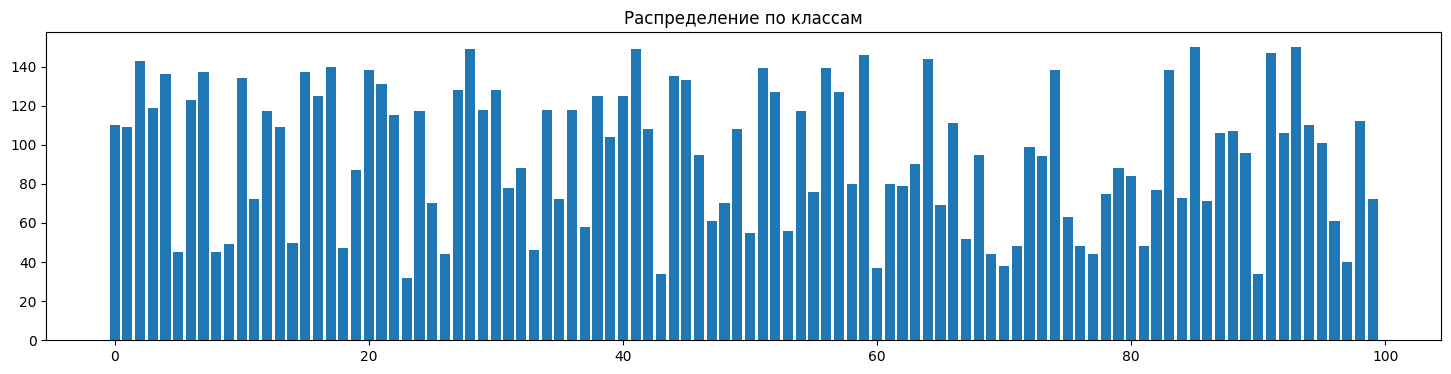

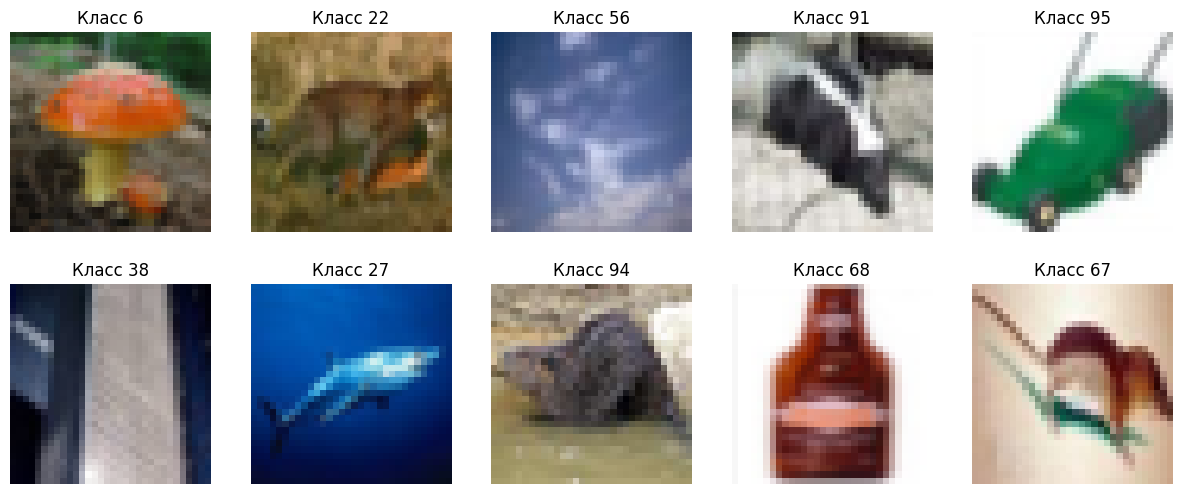

In [ ]:
counts = Counter(labels)
plt.figure(figsize=(18,4))
plt.bar(counts.keys(), counts.values())
plt.title("Распределение по классам")
plt.show()

# Примеры
plt.figure(figsize=(15,6))
for i, cid in enumerate(random.sample(sorted(set(labels)), 10)):
    img = Image.open(glob.glob(f"{train_path}/{cid}/*")[0])
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"Класс {cid}")
    plt.axis("off")
plt.show()

In [ ]:
IMG_SIZE = 224
train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.RGBShift(10,10,10,p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
    ToTensorV2()
])

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        if img is None:
            print(f" Поврежденное изображение: {img_path}")
            return self.__getitem__((idx + 1) % len(self.image_paths))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        return img, self.labels[idx]


In [ ]:
train_p, val_p, train_l, val_l = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=42)
train_ds = CustomDataset(train_p, train_l, transform=train_tf)
val_ds   = CustomDataset(val_p, val_l, transform=val_tf)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
for p in model.parameters(): p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [ ]:
best_acc, patience, counter = 0, 5, 0

for epoch in range(20):
    print(f"\n Эпоха {epoch+1}")
    model.train()
    total, correct, tloss = 0, 0, 0

    for i, (xb, yb) in enumerate(tqdm(train_dl, desc="Обучение")):
        print(f"⚙️ Батч {i+1}/{len(train_dl)}")
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        try:
            out = model(xb)
        except Exception as e:
            print(f" Ошибка в forward pass на батче {i}: {e}")
            continue

        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        tloss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_acc = correct / total

    # === Валидация ===
    model.eval()
    total, correct, vloss = 0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(val_dl, desc="Валидация"):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            vloss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)

    val_acc = correct / total
    print(f" Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Лучшая модель сохранена")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(" Early stopping")
            break



🔁 Эпоха 1


Обучение:   0%|          | 0/238 [00:00<?, ?it/s]

⚙️ Батч 1/238


Обучение:   2%|▏         | 5/238 [00:01<00:51,  4.56it/s]

⚙️ Батч 2/238
⚙️ Батч 3/238
⚙️ Батч 4/238
⚙️ Батч 5/238


...

⚙️ Батч 232/238
⚙️ Батч 233/238
⚙️ Батч 234/238


Обучение: 100%|██████████| 238/238 [00:17<00:00, 16.89it/s]

⚙️ Батч 235/238
⚙️ Батч 236/238
⚙️ Батч 237/238
⚙️ Батч 238/238


Валидация: 100%|██████████| 60/60 [00:03<00:00, 19.11it/s]

✅ Train Acc: 0.5188 | Val Acc: 0.5741


In [50]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
test_imgs = sorted(
    glob.glob(f"{test_path}/*.jpg") +
    glob.glob(f"{test_path}/*.jpeg") +
    glob.glob(f"{test_path}/*.png")
)
test_ds = CustomDataset(test_imgs, [0]*len(test_imgs), transform=val_tf)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

preds = []
with torch.no_grad():
    for xb, _ in tqdm(test_dl, desc="Тест"):
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.argmax(1).cpu().numpy())

Тест: 100%|██████████| 122/122 [00:08<00:00, 15.19it/s]


In [51]:
submission = pd.DataFrame({
    "id": list(range(len(preds))),
    "target": preds
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv сохранён в формате: [id, target]")

✅ submission.csv сохранён в формате: [id, target]
